# Support Vactor Regression

## Project Overview
This notebook demonstrates **Support Vactor Regression** using Python and Scikit-learn.

### Objectives
- Understand the problem statement.
- Import and preprocess the dataset.
- Train the machine learning model.
- Evaluate model performance.
- Make predictions on new data.

---
### Notebook Workflow
1. Import libraries
2. Load dataset
3. Data preprocessing
4. Split data into training and testing sets
5. Train the model
6. Evaluate the model
7. Predict new values
8. Conclusion

> Each code section is followed by comments or can be expanded with explanations for learning purposes.


## Step 1: Import Required Libraries
This section imports all the Python libraries required for data manipulation, visualization, and model building.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## Step 2: Load the Dataset
The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [3]:
df_sal = pd.read_csv('Social_Network_Ads.csv')
df_sal.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df_sal.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
df_sal.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [6]:
df_sal['Gender'] = df_sal['Gender'].map({'Male': 1, 'Female': 0})

In [7]:
X = df_sal[['Age', 'Gender']].values
y = df_sal['EstimatedSalary'].values

In [8]:
sc_X = StandardScaler()
sc_y = StandardScaler()

In [9]:
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1)).ravel()


## Step 4: Train the Model
The algorithm learns patterns from the training dataset.

In [10]:
model = SVR(kernel='rbf')
model.fit(X, y)


SVR()

## Step 5: Make Predictions
The trained model predicts outputs for the test dataset or new observations.

In [11]:
y_pred_scaled = model.predict(X)

In [12]:

y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

## Step 5: Make Predictions
The trained model predicts outputs for the test dataset or new observations.

In [13]:
result = pd.DataFrame({
    'Actual Salary': df_sal['EstimatedSalary'],
    'Predicted Salary': y_pred.flatten()
})


## Step 1: Import Required Libraries
This section imports all the Python libraries required for data manipulation, visualization, and model building.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(df_sal['EstimatedSalary'], y_pred))
print("MSE:", mean_squared_error(df_sal['EstimatedSalary'], y_pred))
print("R2 Score:", r2_score(df_sal['EstimatedSalary'], y_pred))

MAE: 26739.267287796858
MSE: 1122320135.1882002
R2 Score: 0.03222918102450634


## Step 1: Import Required Libraries
This section imports all the Python libraries required for data manipulation, visualization, and model building.

In [15]:
from sklearn.model_selection import train_test_split

X = df_sal[['Age', 'Gender']].values
y = df_sal['EstimatedSalary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(y_train.reshape(-1,1)).ravel()

## Step 4: Train the Model
The algorithm learns patterns from the training dataset.

In [17]:
model = SVR(kernel='rbf')
model.fit(X_train, y_train)

SVR()

## Step 5: Make Predictions
The trained model predicts outputs for the test dataset or new observations.

In [18]:
y_pred_scaled = model.predict(X_test)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1,1))

## Step 6: Evaluate the Model
Performance metrics are used to measure how well the model performs.

In [19]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 25930.134617251268
MSE: 1055900391.706509
R2 Score: 0.00914185899296105


## Step 5: Make Predictions
The trained model predicts outputs for the test dataset or new observations.

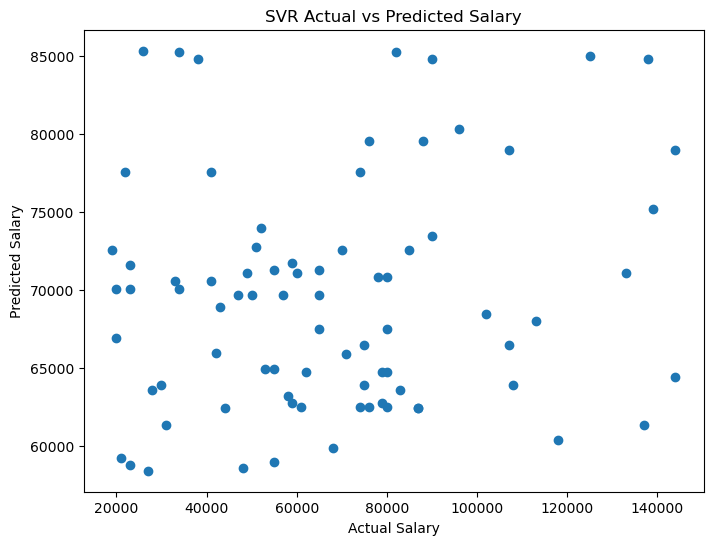

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("SVR Actual vs Predicted Salary")
plt.show()

In [21]:
df_sal.info()
df_sal.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    int64
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(5)
memory usage: 15.8 KB


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

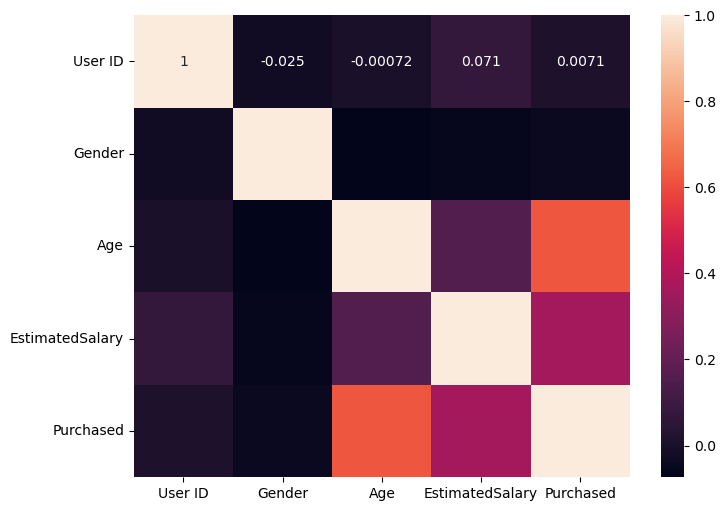

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df_sal.corr(numeric_only=True), annot=True)
plt.show()

In [27]:
SVR(kernel='rbf')

SVR()

In [28]:
SVR(kernel='linear')
SVR(kernel='poly')
SVR(kernel='rbf')

SVR()

## Step 5: Make Predictions
The trained model predicts outputs for the test dataset or new observations.

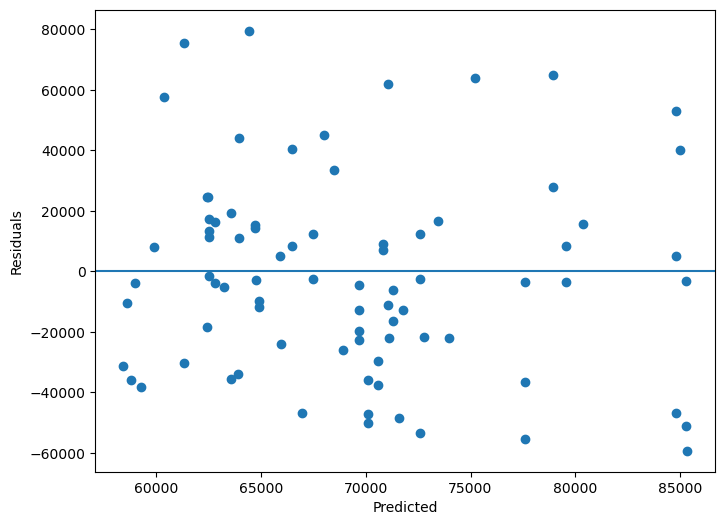

In [29]:
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

## Step 5: Make Predictions
The trained model predicts outputs for the test dataset or new observations.

In [30]:
new_data = [[30, 1]]   # Age=30, Male

new_data_scaled = sc_X.transform(new_data)

pred_salary = model.predict(new_data_scaled)

pred_salary = sc_y.inverse_transform(pred_salary.reshape(-1,1))

print(pred_salary)

[[62464.52573049]]


In [31]:
     import joblib

joblib.dump(model, 'svr_model.pkl')

['svr_model.pkl']

In [32]:
df_sal.info()
df_sal.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    int64
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(5)
memory usage: 15.8 KB


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64